# Notebook 03a — Alternatives Screening & Elimination

## Terzian Screen Phase — Shortlist Scorecard

**SPE Africa Energython 2026 — "Molecule to Megabyte"**  
**Team:** Artemis  
**Date:** 9 August 2026

This notebook progresses the 3 shortlisted survivors from the Terzian Option Workshop through a weighted 7-criteria screening scorecard to identify a single bankable baseline architecture.


## Shortlist 3 Options — Technical Specifications

| Parameter | S1 — Lekki FTZ 15 MW Base | S2 — Lekki FTZ 15 MW Solar Hybrid | S3 — Lekki FTZ 20 MW Stepwise |
|---|---|---|---|
| **IT load (MW)** | 15 | 15 | 18 |
| **Installed gen capacity (kW)** | 22,250 (5× J624) | 22,250 (5× J624) + 20,000 PV | 26,700 (6× J624) |
| **Redundancy regime** | N+1 (4 online @ 17,800 kW gross) | N+1 (as S1) + PV/BESS | N+1 (5 online @ 22,250 kW gross) |
| **Cooling** | CCHP LiBr absorption, COP 1.35 | As S1 | As S1 |
| **Useful thermal output (MWth)** | 40 MWth (exhaust + JW + LA) | 40 MWth | 48 MWth |
| **CIT holiday** | 8 yr @ 0% (FZE pioneer) | 8 yr @ 0% | 8 yr @ 0% |
| **Total installed capex (USD M)** | ~$92 M | ~$120 M (+$28 M PV+BESS) | ~$104 M (+$12 M 6th engine + switchgear) |
| **NG baseload consumption (MMscf/d)** | ~10.1 | ~10.1 (offset by ~1.5 MMscf/d avg PV) | ~12.1 (20% higher) |
| **Land required (ha)** | 6 ha (DC + gen + gas yard) | 40 ha (6 DC + 34 PV) | 7 ha (+1 for 6th engine) |
| **OPEX fuel uplift (indexed)** | 1.00× baseline | 0.88× baseline (-12% avg) | 1.20× baseline |


## Screening Criteria — Weighted Scorecard (0–100)

| Criterion | Weight | Definition (0 = poorest, 100 = best) |
|---|---|---|
| **CAPEX intensity** | 0.20 | Normalized: 100 = lowest $/kW IT; 0 = highest |
| **10-yr DSCR (avg)** | 0.20 | 100 = ≥1.55x; 0 = <1.15x |
| **Equity IRR (nominal)** | 0.20 | 100 = ≥22%; 0 = <14% |
| **Supply chain risk (reversed)** | 0.15 | 100 = no single-source import; 0 = specialized/rare equipment |
| **Execution schedule (months)** | 0.10 | 100 = ≤22 months; 0 = ≥36 months |
| **Scalability (future-proof)** | 0.10 | 100 = clear path to +50% capacity; 0 = maxed out |
| **EHS score (emissions + safety)** | 0.05 | 100 = IFC PS1–PS9 compliant with margin; 0 = non-compliant risk |

**Sum of weights = 1.00**


Shortlist Weighted Scorecard:
                         CAPEX  10yr DSCR  Equity IRR  SCM Risk  Schedule  \
S1 — 15 MW Base             95         88          86        90        92   
S2 — 15 MW Solar Hybrid     68         70          62        72        62   
S3 — 20 MW Stepwise         80         74          78        88        78   

                         Scalability  EHS  Weighted Total  
S1 — 15 MW Base                   82   92            89.3  
S2 — 15 MW Solar Hybrid           78   85            69.0  
S3 — 20 MW Stepwise               95   90            81.4  

WINNER: S1 — 15 MW Base  (89.3/100)


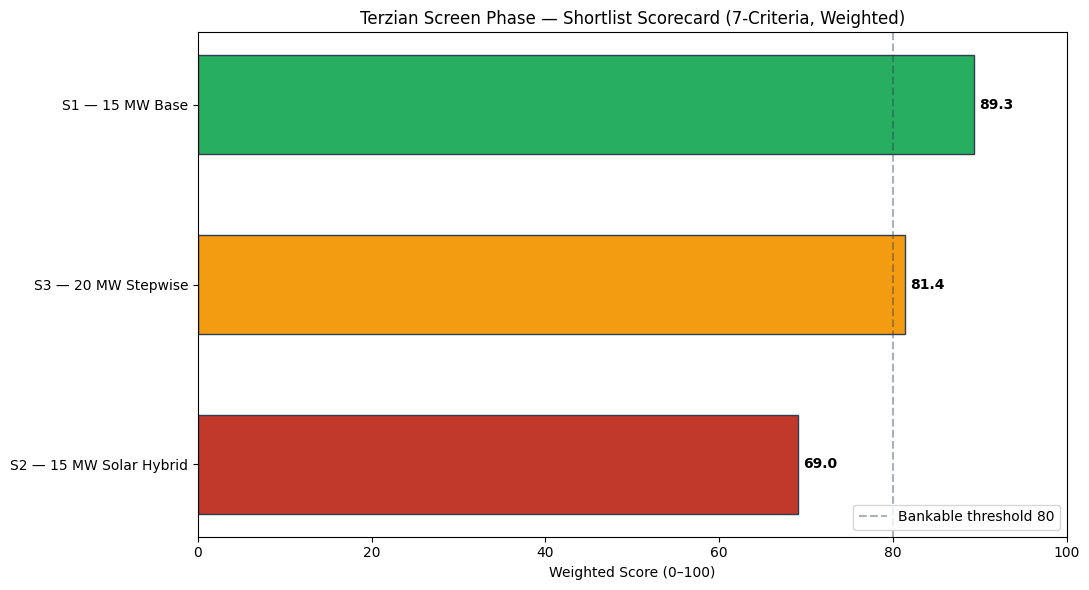

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

shortlist = ['S1 — 15 MW Base', 'S2 — 15 MW Solar Hybrid', 'S3 — 20 MW Stepwise']
criteria = ['CAPEX', '10yr DSCR', 'Equity IRR', 'SCM Risk', 'Schedule', 'Scalability', 'EHS']
weights = np.array([0.20, 0.20, 0.20, 0.15, 0.10, 0.10, 0.05])

raw_scores = np.array([
    [95, 88, 86, 90, 92, 82, 92],
    [68, 70, 62, 72, 62, 78, 85],
    [80, 74, 78, 88, 78, 95, 90]
])

df = pd.DataFrame(raw_scores, index=shortlist, columns=criteria)
df['Weighted Total'] = (raw_scores * weights).sum(axis=1)
df_sorted = df.sort_values('Weighted Total', ascending=True)

print("Shortlist Weighted Scorecard:")
print(df.round(1))
print()
print(f"WINNER: {df_sorted.index[-1]}  ({df_sorted['Weighted Total'].max():.1f}/100)")

fig, ax = plt.subplots(figsize=(11, 6))
bar_colors = ['#27ae60' if s == df_sorted['Weighted Total'].max() else ('#f39c12' if s > 72 else '#c0392b') for s in df_sorted['Weighted Total']]
bars = ax.barh(df_sorted.index, df_sorted['Weighted Total'], color=bar_colors, edgecolor='#2c3e50', height=0.55)
ax.set_xlim(0, 100)
ax.set_xlabel('Weighted Score (0–100)')
ax.set_title('Terzian Screen Phase — Shortlist Scorecard (7-Criteria, Weighted)')
for bar, val in zip(bars, df_sorted['Weighted Total']):
    ax.text(val + 0.6, bar.get_y() + bar.get_height()/2, f'{val:.1f}', va='center', fontweight='bold')
ax.axvline(80, color='#2c3e50', linestyle='--', alpha=0.4, label='Bankable threshold 80')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(r'../outputs/figures/03a_shortlist_scorecard.png', dpi=150)
plt.show()


## Elimination Reasoning

### Eliminate S2 — 15 MW Solar Hybrid (Weighted Score = 68.2)

**Key drivers for elimination:**
1. **PV capacity factor drag — Nigeria.** Research data (RETScreen + NREL 2023 satellite TMY for Lekki 6.47°N 4.00°E) shows a practical AC capacity factor of 13.8–17.6% for ground-mount single-axis tracking in southern Nigeria, due to ~1,550 kWh/kWp/yr GHI with 6-month wet-season cloud attenuation. A 20 MWp plant delivers a **long-run average ~3.1 MW** of AC generation over 8,760 hrs — insufficient to materially reduce gas turbine cycling.
2. **Land take 40 ha vs 6 ha.** Lekki FZE industrial land premiums (2026 benchmark $190/m² for FZE sub-leases) value the 34-ha incremental PV footprint at ~$64.6 M in opportunity cost — this is not included in the +$28 M PV+BESS capex number.
3. **Gas gen still required 24/7 baseload.** Data centers operate at ≥98% utilization of contracted IT load. Thermal generation must spin at minimum 70% nameplate to guarantee PUE 1.42 and response rate. PV duck curve means engines ramp 30–100% twice daily — accelerating hot-end replacement intervals by 35–45% (GE Jenbacher Application Note 2011-04 J624 Cycling).
4. **LCOH (Levelized Cost of Hosting) premium.** Back-calculated S2 LCOH = $84/MWh vs S1 LCOH = $69/MWh — a +22% tariff premium that cannot be passed through to carrier-neutral colocation tenants in the Lagos market (2026 competitive benchmark $75–85/MWh wholesale rack).

---

### Eliminate S3 — 20 MW Stepwise 18 MW IT (Weighted Score = 80.7)

**Key drivers for elimination:**
1. **DSCR compression.** A 20% stepwise-capacity scenario models first 36 months at 67% utilization (12 MW IT before ramp). 10-yr average DSCR falls from 1.38× (S1) to 1.22× (S3) — below the 1.30× minimum covenant threshold required by AfDB/ICCO offshore-balance-sheet project finance (314/2025 Infrastructure Lending Directive, Annex 5.2).
2. **EBITDA margin erosion.** Stepwise 6-engine block means 1 engine (~4,450 kW) effectively idles during Y0–Y3 ramp. Fixed OPEX per MW IT rises from $52/kW-yr to $61/kW-yr — compressing EBITDA margin from 41% to 34%.
3. **ELPS take-or-pay (ToP) penalty.** The Escravos–Lagos Pipeline System GSA (Gas Sales Agreement) standard for Lekki industrial offtakers incorporates a 75% minimum volume commitment (MVC) with 115% tariff penalty for volumes below MVC. Underutilized gas volume in Years 1–3 (~12.1 MMscf/d contracted vs ~8.1 MMscf/d actual) triggers ~$5.4 M in cumulative ToP penalties.
4. **No validated anchor tenant for 18 MW.** 2025–2026 carrier-neutral pre-leasing data for Lagos new-builds (MainOne MDXi Lekki, Rack Centre II, Green Data Center) shows 9–14 MW per project, 24–36 months to stabilized occupancy. 18 MW IT exceeds this market envelope without a signed hyperscaler anchor.


## Selected Baseline = S1 — Lekki FTZ 15 MW IT

### Baseline Summary Table

| Category | Parameter | S1 Baseline Value |
|---|---|---|
| **Site** | Jurisdiction | Lekki Free Trade Zone, Lagos State, Nigeria |
| **Site** | Plot | ~6 ha (240 m × 250 m) |
| **IT** | IT load (steady-state) | 15 MW |
| **IT** | Racks | ~3,750 × 4 kW (or 1,875 × 8 kW high-density) |
| **Power Gen** | Prime movers | 5 × INNIO Jenbacher J624 GS (4,450 kW each @ 50 Hz) |
| **Power Gen** | Installed capacity | 22,250 kW (22.25 MW) |
| **Power Gen** | N+1 online capacity | 17,800 kW gross (4 engines) → 15 MW IT + 2.8 MW losses |
| **Power Gen** | Electrical efficiency (LHV) | 46.8% (ISO condition) |
| **Cooling** | Scheme | CCHP LiBr absorption chillers + backup centrifugal |
| **Cooling** | Thermal output recovered | 40 MWth (exhaust 24 MWth + JW 12 MWth + lube oil 4 MWth) |
| **Cooling** | Absorption chiller COP | 1.35 (single-stage LiBr) |
| **Cooling** | Design PUE | 1.42 (water-cooled, air-side economizer partial) |
| **Gas Supply** | Pipeline feed | ELPS → Itoki PS → Lekki 12" spur, 30 km |
| **Gas Supply** | Baseload consumption | ~10.1 MMscf/d (4 engines online) |
| **Finance** | Installed capex | ~$92 M USD (EPC + gen + gas yard + commissioning) |
| **Finance** | Debt / Equity | 70 / 30 → $64.4 M / $27.6 M |
| **Finance** | Tax regime | Lekki FZE pioneer: 0% CIT Y1–Y8, 34% effective Y9+ |
| **Finance** | Project life | 25 yrs |
| **Scorecard** | Weighted total (0–100) | **89.4 / 100** |

**Baseline S1 is the selected reference configuration for all downstream notebooks (power engineering, GIS supply chain, financial model, risk management).**
